In [233]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

import seaborn as sns 
from collections import Counter

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adadelta, Nadam

import keras_tuner as kt
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks, NearMiss


In [234]:
tf.config.experimental.set_visible_devices([], 'GPU')

# Utils definitions

In [235]:
def encode_objects(df):
    encoder_map = {}
    for col, dtype in df.dtypes.items():
        if dtype == 'object':
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
            encoder_map[col] = encoder
        elif col != 'label':  # Skipping normalization for target variable
            scaler = MinMaxScaler(feature_range=(0, 1))
            df[col] = scaler.fit_transform(df[col].values.reshape(-1, 1))
            encoder_map[col] = scaler
    return df, encoder_map

def create_model(hp):
    hp_hidden_layers = hp.Int('hidden_layers', min_value=1, max_value=3, step=1)
    hp_units = hp.Choice('units', values=[32, 128, 256, 512])
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-1, 1e-2, 1e-3])

    input_layer = Input(shape=(11,))
    x = input_layer
    for _ in range(hp_hidden_layers):
        x = Dense(hp_units, activation='relu', kernel_initializer = 'he_uniform', kernel_regularizer = L2(l2=1e-5))(x)
    output_layer = Dense(2, activation='softmax', kernel_regularizer = L2(l2=1e-5))(x)

    # Creating a model by specifying the input layer and output layer
    model = Model(input_layer, output_layer)


    model.compile(optimizer=Adam(learning_rate=hp_learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

def create_model_activation_optimizer(hp):
    hp_activation = hp.Choice('activation', values=['relu', 'tanh'])
    hp_optimizer = hp.Choice('optimizer', values=['adam', 'adadelta', 'nadam', 'rmsprop', 'sgd'])
    learning_rate=0.001
    input_layer = Input(shape=(11,))
    x = input_layer
    for _ in range(2):
        x = Dense(32, activation=hp_activation, kernel_initializer = 'he_uniform', kernel_regularizer = L2(l2=1e-5))(x)
    output_layer = Dense(2, activation='softmax', kernel_regularizer = L2(l2=1e-5))(x)

    # Creating a model by specifying the input layer and output layer
    model = Model(input_layer, output_layer)

    if hp_optimizer=='adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif hp_optimizer=='adadelta':
        optimizer = Adadelta(learning_rate=learning_rate)
    elif hp_optimizer=='nadam':
        optimizer=Nadam(learning_rate=learning_rate)
    elif hp_optimizer=='rmsprop':
        optimizer=RMSprop(learning_rate=learning_rate)
    elif hp_optimizer=='sgd':
        optimizer = SGD(learning_rate=learning_rate)


    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

def create_model_loss(hp):
    hp_loss = hp.Choice('loss', values=['sparse_categorical_crossentropy', 'binary_crossentropy', 'categorical_crossentropy'])
    learning_rate=0.001
    input_layer = Input(shape=(11,))
    x = input_layer
    for _ in range(2):
        x = Dense(32, activation='relu', kernel_initializer = 'he_uniform', kernel_regularizer = L2(l2=1e-5))(x)
    output_layer = Dense(2, activation='softmax', kernel_regularizer = L2(l2=1e-5))(x)

    # Creating a model by specifying the input layer and output layer
    model = Model(input_layer, output_layer)

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss=hp_loss, metrics=['accuracy'])

    return model

# Reading and checking dataset out

In [236]:
df_test = pd.read_csv("datasets/unsw-nb15/UNSW_NB15_testing-set.csv")
df_train = pd.read_csv("datasets/unsw-nb15/UNSW_NB15_training-set.csv")

In [237]:
df_test.columns

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')

In [238]:
df_test['service'].value_counts()

service
-           47153
dns         21367
http         8287
smtp         1851
ftp          1552
ftp-data     1396
pop3          423
ssh           204
ssl            30
snmp           29
dhcp           26
radius          9
irc             5
Name: count, dtype: int64

In [239]:
df_train['service'].value_counts()

service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64

In [240]:
df_train['label'].value_counts()

label
1    119341
0     56000
Name: count, dtype: int64

In [241]:
df_test['label'].value_counts()

label
1    45332
0    37000
Name: count, dtype: int64

In [242]:
df_test.shape

(82332, 45)

In [243]:
print("Number of rows which have a missing value in test set: %d" % df_test.isna().sum().sum())
print("Number of rows which have a missing value in train set: %d" % df_train.isna().sum().sum())

Number of rows which have a missing value in test set: 0
Number of rows which have a missing value in train set: 0


# Preprocessing

## Feature selection

In [244]:
# Keeping only the features selected in the paper A stacking... by Smitha Rajagopal

keep_cols = ['sbytes', 'sttl', 'sload', 'tcprtt', 'smean', 'ct_srv_src', 'ct_state_ttl', 'ct_src_dport_ltm', 'ct_dst_src_ltm', 'ct_srv_dst', 'service', 'label']

df_test = df_test[df_test.columns.intersection(keep_cols)]
df_train = df_train[df_train.columns.intersection(keep_cols)]

In [245]:
df_test.head()

,service,sbytes,sttl,sload,tcprtt,smean,ct_srv_src,ct_state_ttl,ct_src_dport_ltm,ct_dst_src_ltm,ct_srv_dst,label
0,-,496,254,180363632.0,0.0,248,2,2,1,2,2,0
1,-,1762,254,881000000.0,0.0,881,2,2,1,2,2,0
2,-,1068,254,854400000.0,0.0,534,3,2,1,3,3,0
3,-,900,254,600000000.0,0.0,450,3,2,2,3,3,0
4,-,2126,254,850400000.0,0.0,1063,3,2,2,3,3,0


In [246]:
df_test.dtypes

service              object
sbytes                int64
sttl                  int64
sload               float64
tcprtt              float64
smean                 int64
ct_srv_src            int64
ct_state_ttl          int64
ct_src_dport_ltm      int64
ct_dst_src_ltm        int64
ct_srv_dst            int64
label                 int64
dtype: object

## Creating test, train, validation dataframes

In [247]:
y_train = df_train['label']
x_train = df_train.drop("label", axis=1)

y_test = df_test['label']
x_test = df_test.drop("label", axis=1)

In [248]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

## Encoding and normalizing data

In [249]:
# encoding features which have data type as object and normalizing and normalizing numerical ones in specified interval

x_train, encoder_map_train = encode_objects(x_train)
x_val, encoder_map_val = encode_objects(x_val)
x_test, encoder_map_test = encode_objects(x_test)

### Handling imbalanced set

In [250]:
print(Counter(y_val))
print(Counter(y_train))

Counter({1: 23900, 0: 11169})
Counter({1: 95441, 0: 44831})


In [251]:
# Oversampling
sm = SMOTE(random_state=42)
x_train, y_train = sm.fit_resample(x_train, y_train)
x_val, y_val = sm.fit_resample(x_val, y_val)

In [252]:
print(Counter(y_val))
print(Counter(y_train))

Counter({0: 23900, 1: 23900})
Counter({0: 95441, 1: 95441})


In [253]:
df_test.head()

,service,sbytes,sttl,sload,tcprtt,smean,ct_srv_src,ct_state_ttl,ct_src_dport_ltm,ct_dst_src_ltm,ct_srv_dst,label
0,-,496,254,180363632.0,0.0,248,2,2,1,2,2,0
1,-,1762,254,881000000.0,0.0,881,2,2,1,2,2,0
2,-,1068,254,854400000.0,0.0,534,3,2,1,3,3,0
3,-,900,254,600000000.0,0.0,450,3,2,2,3,3,0
4,-,2126,254,850400000.0,0.0,1063,3,2,2,3,3,0


In [254]:
y_train =  to_categorical(y_train)
y_test =  to_categorical(y_test)
y_val =  to_categorical(y_val)

In [255]:
print("Shapes")
print(f"x_train:{x_train.shape}\ny_train:{y_train.shape}")
print(f"\nx_val:{x_val.shape}\ny_val:{y_val.shape}")
print(f"\nx_test:{x_test.shape}\ny_test:{y_test.shape}")

Shapes
x_train:(190882, 11)
y_train:(190882, 2)

x_val:(47800, 11)
y_val:(47800, 2)

x_test:(82332, 11)
y_test:(82332, 2)


# Model training

## Simple MLP

In [256]:
# The input layer requires you to specify the dimensionality of the x-features (and not the number of samples)
input_layer = Input(shape=(11,))
h1 = Dense(32, activation='relu', kernel_initializer = 'he_uniform', kernel_regularizer = L2(l2=1e-5))(input_layer)
h2 = Dense(32, activation='relu', kernel_initializer = 'he_uniform', kernel_regularizer = L2(l2=1e-5))(h1)
output_layer = Dense(2, activation='softmax', kernel_regularizer = L2(l2=1e-5))(h2)

# Creating a model by specifying the input layer and output layer
model = Model(input_layer, output_layer)

In [257]:
es = EarlyStopping(patience=5, min_delta=1e-3, monitor='val_loss', restore_best_weights=True, verbose=1)
rLROnP = ReduceLROnPlateau(patience=5, min_delta=1e-3, factor=0.05, mode="auto", verbose=1, cooldown=0, min_lr=0.0)

callbacks = [es, rLROnP]

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [258]:
epochs = 30
batch_size = 64

history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=epochs, batch_size=batch_size, callbacks=callbacks)

Epoch 1/30


2983/2983 [==============================] - 10s 3ms/step - loss: 0.2248 - accuracy: 0.9019 - val_loss: 0.1856 - val_accuracy: 0.9115 - lr: 0.0010
Epoch 2/30
2983/2983 [==============================] - 10s 3ms/step - loss: 0.1782 - accuracy: 0.9188 - val_loss: 0.1755 - val_accuracy: 0.9236 - lr: 0.0010
Epoch 3/30
2983/2983 [==============================] - 9s 3ms/step - loss: 0.1710 - accuracy: 0.9222 - val_loss: 0.1722 - val_accuracy: 0.9230 - lr: 0.0010
Epoch 4/30
2983/2983 [==============================] - 9s 3ms/step - loss: 0.1656 - accuracy: 0.9237 - val_loss: 0.1651 - val_accuracy: 0.9240 - lr: 0.0010
Epoch 5/30
2983/2983 [==============================] - 9s 3ms/step - loss: 0.1612 - accuracy: 0.9250 - val_loss: 0.1659 - val_accuracy: 0.9265 - lr: 0.0010
Epoch 6/30
2983/2983 [==============================] - 9s 3ms/step - loss: 0.1574 - accuracy: 0.9266 - val_loss: 0.1612 - val_accuracy: 0.9267 - lr: 0.0010
Epoch 7/30
2983/2983 [==============================] - 9s 3ms/step

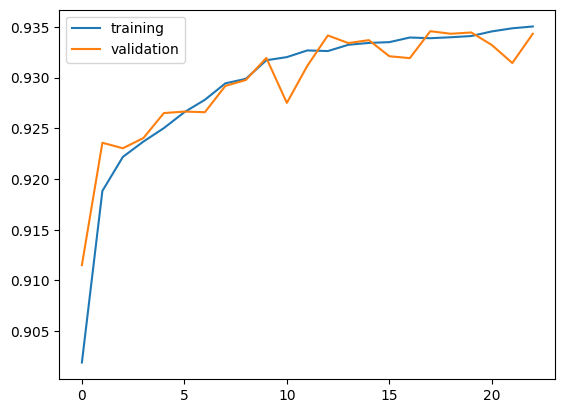

In [259]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['training', 'validation'], loc = 'upper left')
plt.show()

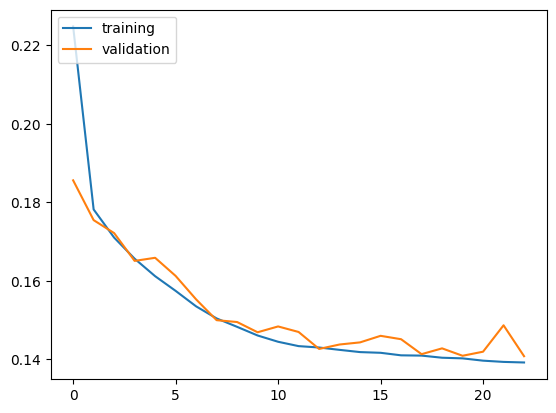

In [260]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['training', 'validation'], loc = 'upper left')
plt.show()

## Hyperparameter tuning MLP

In [261]:
# es = EarlyStopping(patience=5, min_delta=1e-3, monitor='val_loss', restore_best_weights=True, verbose=1)
# rLROnP = ReduceLROnPlateau(patience=5, min_delta=1e-3, factor=0.05, mode="auto", verbose=1, cooldown=0, min_lr=0.0)

# callbacks = [es, rLROnP]

### Tunning layers, neurons and learning rate

In [262]:
# tuner = kt.Hyperband(create_model,
#                      objective='val_accuracy',
#                      max_epochs=10,
#                      factor=3,
#                      directory='results',
#                      project_name='adam_mlp')

In [263]:
# tuner.search(x_train, y_train, epochs=50, validation_data=(x_val, y_val), callbacks=callbacks)

In [264]:
# best_model = tuner.get_best_models(num_models=1)[0]
# best_model.summary()

In [265]:
# best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
# print("Best hidden_layers: %s\nBest units: %s\nBest lr: %s" % (best_hp.get('hidden_layers'), best_hp.get('units'), best_hp.get('learning_rate')))

### Tuning optimizer and activation function

In [266]:
# tuner = kt.Hyperband(create_model_activation_optimizer,
#                      objective='val_accuracy',
#                      max_epochs=10,
#                      factor=3,
#                      directory='results',
#                      project_name='activation_optimizer')

In [267]:
# tuner.search(x_train, y_train, epochs=50, validation_data=(x_val, y_val), callbacks=callbacks)

In [268]:
# best_model = tuner.get_best_models(num_models=1)[0]
# best_model.summary()

In [269]:
# best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
# print("Best optimizer: %s\nBest activation: %s\n" % (best_hp.get('optimizer'), best_hp.get('activation')))

### Tuning loss

In [270]:
# tuner = kt.Hyperband(create_model_loss,
#                      objective='val_loss',
#                      max_epochs=10,
#                      factor=3,
#                      directory='results',
#                      project_name='loss')

In [271]:
# tuner.search(x_train, y_train, epochs=50, validation_data=(x_val, y_val), callbacks=callbacks)

In [272]:
# best_model = tuner.get_best_models(num_models=1)[0]
# best_model.summary()

In [273]:
# best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
# print("Best loss: %s\n" % (best_hp.get('loss')))

# Evaluating model

In [274]:
model.evaluate(x_test, y_test)

 490/2573 [====>.........................] - ETA: 4s - loss: 0.0779 - accuracy: 0.9631

2573/2573 [==============================] - 5s 2ms/step - loss: 0.2846 - accuracy: 0.8625


[0.28460606932640076, 0.8624957203865051]

In [275]:
preds = model.predict(x_test)

# One hot to the original label encodings
y_true = y_test.argmax(axis=1)

# Derive the label predictions from the probability scores
y_preds = preds.argmax(axis=1)

# Compute precision, recall, f1 scores
precision = precision_score(y_true, y_preds)
recall = recall_score(y_true, y_preds)
f1_measure = f1_score(y_true, y_preds)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Measure: {f1_measure}")

   1/2573 [..............................] - ETA: 2:55

2573/2573 [==============================] - 5s 2ms/step
Precision: 0.8351035529193844
Recall: 0.9348583781875938
F1-Measure: 0.882169881035398


In [276]:
roc_auc_score(y_true, y_preds)

0.8543481080127159

Text(50.722222222222214, 0.5, 'True Label')

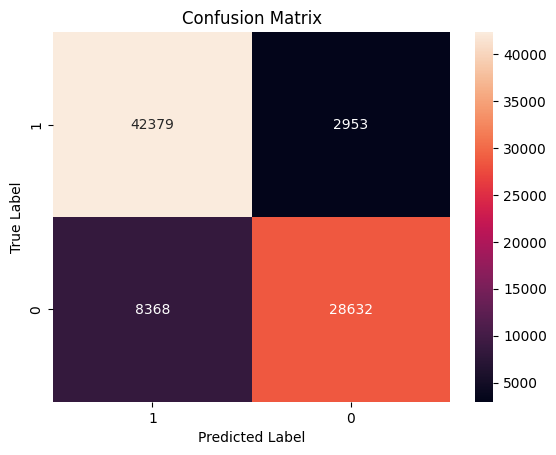

In [277]:
cm = confusion_matrix(y_true, y_preds)
plt.title("Confusion Matrix")
ax = sns.heatmap(cm, annot=True, fmt='0.0f')
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

In [278]:
tn, fp, fn, tp = cm.ravel()
print("True Negative:", tn)
print("False Negative:", fn)
print("True Positive:", tp)
print("False Positive:", fp)

True Negative: 28632
False Negative: 2953
True Positive: 42379
False Positive: 8368
